In [1]:
import pandas as pd
import numpy as np
from scipy.linalg import solve
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
from collections import defaultdict
import csv
 

In [4]:
b_raw = pd.read_csv("poc_buses.csv")
l_raw = pd.read_csv("poc_lines.csv")
print(b_raw)

     name  v_nom  type         x          y carrier  unit  location  \
0   NL0 0  380.0   NaN  4.580489  51.975314      AC   NaN       NaN   
1   NL0 1  380.0   NaN  6.925060  53.288277      AC   NaN       NaN   
2  NL0 10  380.0   NaN  6.759179  52.248853      AC   NaN       NaN   

   v_mag_pu_set  v_mag_pu_min  v_mag_pu_max control  generator  sub_network  \
0           1.0           0.0           inf   Slack        NaN            0   
1           1.0           0.0           inf      PQ        NaN            0   
2           1.0           0.0           inf      PQ        NaN            0   

  country  substation_lv  substation_off  
0      NL            1.0             1.0  
1      NL            1.0             1.0  
2      NL            1.0             1.0  


In [5]:
# clean the data, keeping only columns we need and get rid of empty rows
buses = b_raw[["name"]].copy()
# drop H2 and battery buses, not relevant for our analysis
buses = buses[~buses["name"].str.contains("H2|battery", case=False, na=False)]


# data needed from lines: name, bus0, bus1, reactance x and capacity s_nom
lines = l_raw[["name", "bus0", "bus1", "x", "r", "s_nom"]].copy()
# for line capacity: "s_nom" multplied with "s_max_pu" to recover the usable capacity
# drop lines if value is missing or 0 for any of the columns
lines = lines.dropna(subset=["name", "bus0", "bus1", "x", "r", "s_nom"])
lines = lines[(lines["x"] != 0) & (lines["r"] != 0) & (lines["s_nom"] != 0)]
print(lines)

   name   bus0    bus1         x         r  s_nom
0     0  NL0 0   NL0 1  4.257970  0.519264      5
1     1  NL0 1  NL0 10  2.672492  0.325914     65


In [6]:
# reactance-resistance ratio of the lines to check suitability for DC power flow approximation (neglectable ratio > 4)
avg_xr_ratio = (lines["x"] / lines["r"]).mean()
min_xr_ratio = (lines["x"] / lines["r"]).min()
max_xr_ratio = (lines["x"] / lines["r"]).max()
print(f"Average x/r ratio: {avg_xr_ratio:.2f}")
print(f"Minimum x/r ratio: {min_xr_ratio:.2f}")     
print(f"Maximum x/r ratio: {max_xr_ratio:.2f}")

Average x/r ratio: 8.20
Minimum x/r ratio: 8.20
Maximum x/r ratio: 8.20


In [7]:
# indices for buses and lines
buses["bus_idx"] = np.arange(len(buses))
lines["line_idx"] = np.arange(len(lines))
# create a mapping from bus name to bus index
bus_name_to_idx = dict(zip(buses["name"], buses["bus_idx"]))

# map line endpoints to bus indices
lines["bus0_idx"] = lines["bus0"].map(bus_name_to_idx)
lines["bus1_idx"] = lines["bus1"].map(bus_name_to_idx)
print(lines[["name", "bus0", "bus1", "bus0_idx", "bus1_idx"]])

   name   bus0    bus1  bus0_idx  bus1_idx
0     0  NL0 0   NL0 1         0         1
1     1  NL0 1  NL0 10         1         2


In [8]:
# incidence matrix A, where A[l, bus0] = +1 (from) and A[l, bus1] = -1 (to)
num_buses = len(buses)
num_lines = len(lines)
A = np.zeros((num_lines, num_buses), dtype=int)

for _, row in lines.iterrows():
    bus0 = row["bus0_idx"]
    bus1 = row["bus1_idx"]
    l = row["line_idx"]
    A[l, bus0] = 1
    A[l, bus1] = -1
print("Incidence matrix shape:", A.shape)
print(buses[["bus_idx", "name"]].head(10))
display(pd.DataFrame(A[:24, :20]))
row_sums = A.sum(axis=1)
print("\nUnique row sums of A (should be 0):", np.unique(row_sums))

Incidence matrix shape: (2, 3)
   bus_idx    name
0        0   NL0 0
1        1   NL0 1
2        2  NL0 10


,0,1,2
0,1,-1,0
1,0,1,-1



Unique row sums of A (should be 0): [0]


In [9]:
# save the ordering tables for later export
buses[["bus_idx", "name"]].to_csv("poc_bus_order.csv", index=False)
lines[["line_idx", "name", "bus0", "bus1", "x", "s_nom"]].to_csv("poc_line_order.csv", index=False)

In [10]:
# define reference bus
ref_bus_name = buses.loc[0, "name"]  # choose the first bus as reference
ref_bus_idx = int(buses.loc[buses["name"] == ref_bus_name, "bus_idx"].iloc[0])  # explanation: get the index of the reference bus
print(f"Reference bus: {ref_bus_name} index({ref_bus_idx})")

Reference bus: NL0 0 index(0)


In [11]:
# line susceptance vector b = 1/x
x = lines["x"].to_numpy(dtype=float)
b = 1 / x

# build diagonal matrix B = diag(b)
B = np.diag(b)

# remove the reference bus column from A to get A_red
A_red = np.delete(A, ref_bus_idx, axis=1)

# compute reduced bus susceptance matrix
B_red = A_red.T @ B @ A_red

print("Reduced bus susceptance matrix B_red shape:", B_red.shape)
print("A_red shape:", A_red.shape)

Reduced bus susceptance matrix B_red shape: (2, 2)
A_red shape: (2, 2)


In [12]:
# solve (instead of invert)
PTDF_red = np.linalg.solve(B_red, (B @ A_red).T).T
print("PTDF_red shape:", PTDF_red.shape)

PTDF_red shape: (2, 2)


In [13]:
# insert zero column back at the slack position
PTDF = np.insert(PTDF_red, ref_bus_idx, 0.0, axis=1)
print("Final PTDF shape:", PTDF.shape)


ptdf_df = pd.DataFrame(
    PTDF,
    index=lines["name"],
    columns=buses["name"]
)

# change column names to Bus, row names to Line for easier reference
ptdf_df.columns.name = "Bus"
ptdf_df.index.name = "Line"

display(ptdf_df.iloc[:20, :20])

ptdf_df.to_csv("nl34_ptdf_matrix.csv")

Final PTDF shape: (2, 3)


Bus,NL0 0,NL0 1,NL0 10
Line,,,
0,0.0,-1.0,-1.0
1,0.0,0.0,-1.0


In [15]:
# sanity check: test transfer and see if the resulting flows make sense
# inject +1 at one bus and withdraw -1 at another bus
inj_bus = buses.loc[1, "name"] if len(buses) > 1 else buses.loc[1, "name"]
wdr_bus = ref_bus_name

inj_idx = int(buses.loc[buses["name"] == inj_bus, "bus_idx"].iloc[0])
wdr_idx = int(buses.loc[buses["name"] == wdr_bus, "bus_idx"].iloc[0])

p_test = np.zeros(len(buses))
p_test[inj_idx] = 1.0
p_test[wdr_idx] = -1.0
print("Sum of test injections (should be 0):", p_test.sum())

f_test = PTDF @ p_test

flow_test_df = pd.DataFrame({
    "line": lines["name"],
    "flow_for_test_transfer": f_test
})

print(f"\nTest transfer: +1 MW at {inj_bus}, -1 MW at {wdr_bus}")
display(flow_test_df.head(10))

Sum of test injections (should be 0): 0.0

Test transfer: +1 MW at NL0 1, -1 MW at NL0 0


,line,flow_for_test_transfer
0,0,-1.0
1,1,0.0


In [17]:
inj_idx = 0
slack_idx = ref_bus_idx

p = np.zeros(len(buses))
p[inj_idx] = 1.0
p[slack_idx] = -1.0

# remove slack entry from injections
p_red = np.delete(p, slack_idx)

# solve reduced DC load flow for voltage angles
theta_red = np.linalg.solve(B_red, p_red)

# reconstruct full angle vector
theta = np.insert(theta_red, slack_idx, 0.0)

# compute line flows from angles
f_dc = np.diag(b) @ A @ theta

# compute line flows from PTDF
f_ptdf = PTDF @ p

# compare
comparison_df = pd.DataFrame({
    "line": lines["name"].values,
    "flow_ptdf": f_ptdf,
    "flow_dc": f_dc,
    "difference": f_ptdf - f_dc
})

print("Max absolute difference:", np.max(np.abs(f_ptdf - f_dc)))
display(comparison_df)

Max absolute difference: 0.0


,line,flow_ptdf,flow_dc,difference
0,0,0.0,0.0,0.0
1,1,0.0,0.0,0.0


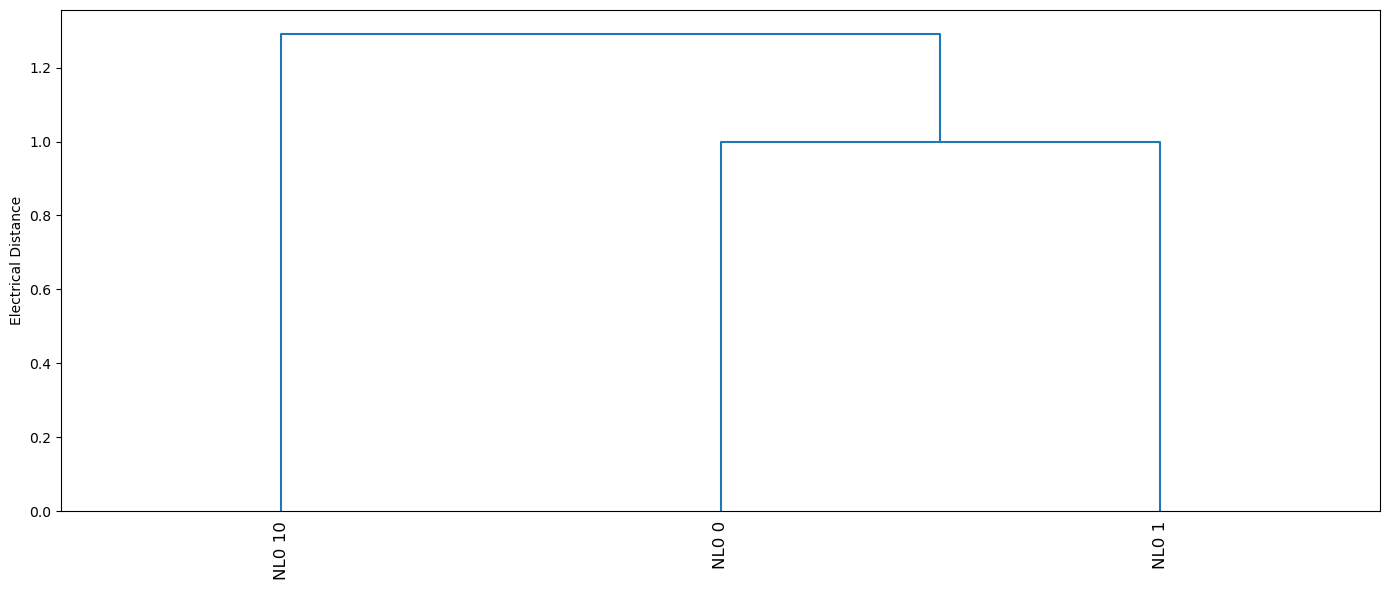

In [18]:
# PTDF is (lines × nodes) matrix
# Each column = how a 1 MW injection at that node affects all line flows
# Euclidean distance between columns = electrical distance between nodes

bus_names = buses["name"].values
node_signatures = PTDF.T  # (nodes × lines)


distances = pdist(node_signatures, metric='euclidean')
Z = linkage(distances, method='ward')

# Plot dendrogram
plt.figure(figsize=(14, 6))
dendrogram(Z, labels=bus_names, leaf_rotation=90)
plt.ylabel("Electrical Distance")
plt.tight_layout()
plt.show()

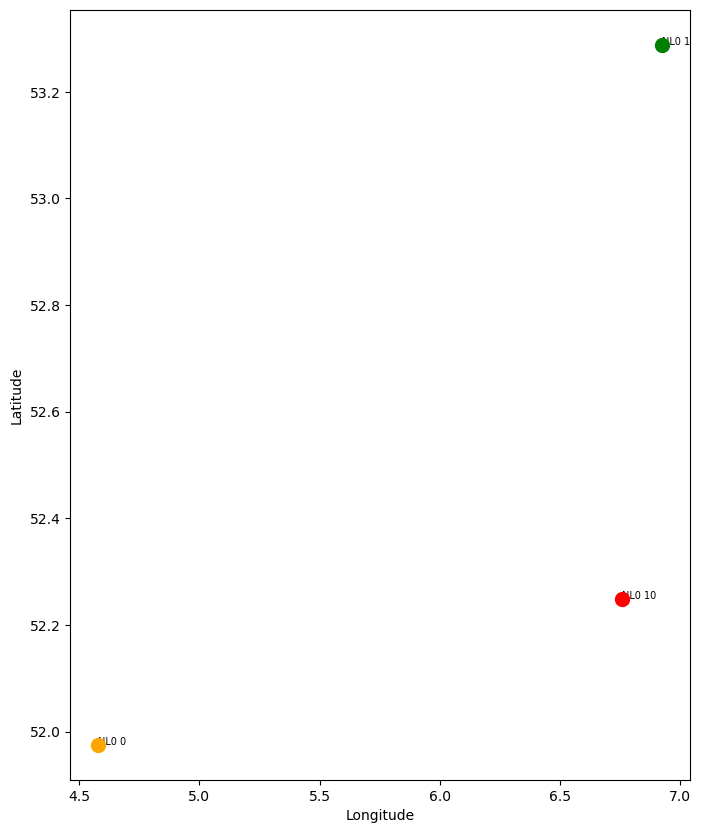

In [19]:
# Plot buses colored by zone on a map
colors_map = {1: 'orange', 2: 'green', 3: 'red', 4: 'blue'}
zone_labels = fcluster(Z, t=3, criterion='maxclust')

plt.figure(figsize=(8, 10))
for i, (_, bus) in enumerate(buses.iterrows()):
    if bus["name"] in bus_names:
        idx = list(bus_names).index(bus["name"])
        plt.scatter(b_raw.loc[b_raw["name"] == bus["name"], "x"], 
                    b_raw.loc[b_raw["name"] == bus["name"], "y"], 
                    c=colors_map[zone_labels[idx]], s=100, zorder=5)
        plt.annotate(bus["name"], (b_raw.loc[b_raw["name"] == bus["name"], "x"].values[0], 
                                   b_raw.loc[b_raw["name"] == bus["name"], "y"].values[0]), fontsize=7)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [20]:
# Cut into k zones
k = 3
zone_labels = fcluster(Z, t=k, criterion='maxclust')

for zone in range(1, k+1):
    members = bus_names[zone_labels == zone]
    print(f"Zone {zone}: {list(members)}")

Zone 1: ['NL0 0']
Zone 2: ['NL0 1']
Zone 3: ['NL0 10']


In [21]:
# add zones to bus csv
buses["zone"] = zone_labels
print(buses)
buses.to_csv("poc_bus_order.csv", index=False)

     name  bus_idx  zone
0   NL0 0        0     1
1   NL0 1        1     2
2  NL0 10        2     3


In [23]:
buses_mec = pd.read_csv('poc_bus_order.csv')
lines_mec = pd.read_csv('poc_line_order.csv')

lines_mec = (lines_mec
    .merge(buses_mec[['name','zone']], left_on='bus0', right_on='name', suffixes=('','_b0'))
    .rename(columns={'zone': 'zone0'})
    .drop(columns='name_b0', errors='ignore')
    .merge(buses_mec[['name','zone']], left_on='bus1', right_on='name', suffixes=('','_b1'))
    .rename(columns={'zone': 'zone1'})
    .drop(columns='name_b1', errors='ignore')
)
 
lines_mec['inter_zonal'] = lines_mec['zone0'] != lines_mec['zone1']
lines_mec['pair'] = lines_mec.apply(lambda r: (min(r['zone0'],r['zone1']), max(r['zone0'],r['zone1'])), axis=1)

cross = lines_mec[lines_mec['inter_zonal']].copy()
print(cross[['line_idx','bus0','zone0','bus1','zone1','s_nom','x']].to_string(index=False))
 
mec = (cross.groupby('pair')['s_nom']
    .sum().reset_index())
mec[['zone_1','zone_2']] = pd.DataFrame(mec['pair'].tolist(), index=mec.index)
mec = mec.rename(columns={'s_nom': 'mec_MW'})[['zone_1', 'zone_2', 'mec_MW']]
 
mec.to_csv('poc_interzonal_mec.csv', index=False)
print(mec)

 line_idx  bus0  zone0   bus1  zone1  s_nom        x
        0 NL0 0      1  NL0 1      2      5 4.257970
        1 NL0 1      2 NL0 10      3     65 2.672492
   zone_1  zone_2  mec_MW
0       1       2       5
1       2       3      65
